<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [ ]:
# Your code here
import pandas as pd
import numpy as np

df = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")
# print(df)

fare_amount = sum(df["fare_amount"])
print(fare_amount)

tip_amount = sum(df["tip_amount"])
print(tip_amount)

tolls_amount = sum(df["tolls_amount"])
print(tolls_amount)

total_amount = sum(df["total_amount"])
print(total_amount)


151063.13
26344.94
6234.47
225646.59


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [14]:
# Your code here
longest_trip = df.loc[df["trip_distance"].idxmax()]
# print(longest_trip)

longest_trip_result = longest_trip[["fare_amount", "tip_amount", "tolls_amount", "total_amount"]]
print(longest_trip_result)


fare_amount      176.0
tip_amount       18.29
tolls_amount      6.12
total_amount    201.21
Name: 8338, dtype: object


<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [109]:
# Your code here
df_m = pd.read_csv("data/Meteorite_Landings.csv")

In [110]:
df_m = df_m.rename(columns={"mass (g)":"mass"})
# print(df_m.columns)

df_m = df_m.drop(columns=["reclat", "reclong"], errors="ignore")
print(df_m.columns)

Index(['name', 'id', 'nametype', 'recclass', 'mass', 'fall', 'year',
       'GeoLocation'],
      dtype='object')


In [61]:
df_m = df_m.sort_values(by="mass", ascending=False)
print(df_m)
# df_m[df_m["year"].isna()]

                  name     id nametype      recclass        mass   fall  \
16392             Hoba  11890    Valid     Iron, IVB  60000000.0  Found   
5373         Cape York   5262    Valid   Iron, IIIAB  58200000.0  Found   
5365   Campo del Cielo   5247    Valid  Iron, IAB-MG  50000000.0  Found   
5370     Canyon Diablo   5257    Valid  Iron, IAB-MG  30000000.0  Found   
3455           Armanty   2335    Valid    Iron, IIIE  28000000.0  Found   
...                ...    ...      ...           ...         ...    ...   
38282   Wei-hui-fu (a)  24231    Valid          Iron         NaN  Found   
38283   Wei-hui-fu (b)  24232    Valid          Iron         NaN  Found   
38285          Weiyuan  24233    Valid  Mesosiderite         NaN  Found   
41472    Yamato 792768  28117    Valid           CM2         NaN  Found   
45698    Zapata County  30393    Valid          Iron         NaN  Found   

         year             GeoLocation  
16392  1920.0   (-19.58333, 17.91667)  
5373   1818.0   (76

<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [111]:
# Your code here
df_m["year"] = df_m["year"].str.slice(6, 10)
print(df_m["year"])

0        1880
1        1951
2        1952
3        1976
4        1902
         ... 
45711    1990
45712    1999
45713    1939
45714    2003
45715    1976
Name: year, Length: 45716, dtype: object


In [112]:
df_m["year"] = pd.to_numeric(df_m["year"])
print(df_m["year"])

0        1880.0
1        1951.0
2        1952.0
3        1976.0
4        1902.0
          ...  
45711    1990.0
45712    1999.0
45713    1939.0
45714    2003.0
45715    1976.0
Name: year, Length: 45716, dtype: float64


In [113]:
df_m["fell_before_1970"] = ((df_m["fall"].str.lower() == "fell") & (df_m["year"] < 1970))
print(df_m["fell_before_1970"])

0         True
1         True
2         True
3        False
4         True
         ...  
45711    False
45712    False
45713    False
45714    False
45715    False
Name: fell_before_1970, Length: 45716, dtype: bool


In [114]:
df_m = df_m.set_index('id').sort_index()

In [115]:
df_m.loc[10036:10040]

,name,nametype,recclass,mass,fall,year,GeoLocation,fell_before_1970
id,,,,,,,,
10036,Enigma,Valid,H4,94.0,Found,1967.0,"(31.33333, -82.31667)",False
10037,Enon,Valid,"Iron, ungrouped",763.0,Found,1883.0,"(39.86667, -83.95)",False
10038,Enshi,Valid,H5,8000.0,Fell,1974.0,"(30.3, 109.5)",False
10039,Ensisheim,Valid,LL6,127000.0,Fell,1491.0,"(47.86667, 7.35)",True


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [ ]:
# Your code here
df_m['year'].unique()

array([1880., 1951., 1982., 1952., 1941., 1840., 1997., 1976., 1989.,
       1990., 1991., 1992., 2001., 2002., 1924., 1902., 1947., 1962.,
       1981., 1883., 1928., 1961., 1972., 1912., 1919., 1881., 1936.,
       1949., 1814., 1942., 2000., 1938., 1930., 1971., 1993., 1920.,
       1909., 1907., 1974., 1925., 1769., 1838., 1968., 1988., 1940.,
       1959., 2003., 1957., 1806., 1937., 1766., 1915., 1966., 1985.,
       1996., 1835., 1873., 1860., 1875., 1900., 1960., 1887., 1931.,
       1977., 1955., 1998., 1973., 1983., 1984., 1986., 1987., 1994.,
       1995., 1999., 1978., 1979., 1980., 1899., 1923., 1969., 1898.,
       1932., 1895., 1934., 1889., 1939., 1916., 1822., 1869., 1970.,
       1965., 1914., 1803., 1954., 1896., 1894., 1908., 1967., 1950.,
         nan, 1805., 1839., 1901., 1846., 1886., 1933., 1945., 1963.,
       1964., 1836., 1867., 1858., 1890., 1865., 1842., 1855., 1943.,
       1876., 1863., 1904., 1891., 1929., 1922., 1927., 1892., 1871.,
       1913., 1918.,

In [120]:
df_m.loc[df_m["year"].isna()]

,name,nametype,recclass,mass,fall,year,GeoLocation,fell_before_1970
id,,,,,,,,
2344,Asarco Mexicana,Valid,"Iron, IIIAB",NaN,Found,NaN,NaN,False
4902,Aus,Valid,L,30.2,Found,NaN,"(-26.66667, 16.25)",False
5012,Benares (b),Valid,Iron,NaN,Found,NaN,"(25.33333, 83.0)",False
5191,Cacilandia,Valid,H6,NaN,Found,NaN,NaN,False
5199,California,Valid,"Iron, IAB-sLL",NaN,Found,NaN,NaN,False
...,...,...,...,...,...,...,...,...
56528,Jiddat al Harasis 796,Valid,L5,22.8,Found,NaN,"(19.80861, 55.74861)",False
56529,Jiddat Arkad 003,Valid,L5,148.0,Found,NaN,"(18.96889, 56.42611)",False
56530,Jiddat al Harasis 797,Valid,L5,249.0,Found,NaN,"(19.73306, 55.57111)",False


There's a meteorite that was reportedly found in the future:

In [121]:
# Your code here
max(df_m["year"])

2101.0

In [122]:
df_m.loc[df_m['year'] == 2101]

,name,nametype,recclass,mass,fall,year,GeoLocation,fell_before_1970
id,,,,,,,,
57150,Northwest Africa 7701,Valid,CK6,55.0,Found,2101.0,"(0.0, 0.0)",False


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [127]:
# Your code here
df_f = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")

In [128]:
df_f['tpep_dropoff_datetime'] = pd.to_datetime(df_f["tpep_dropoff_datetime"])

In [138]:
df_f_reind = df_f.set_index("tpep_dropoff_datetime")
df_f_resamp = df_f_reind.resample("h").sum()

In [139]:
distance = sum(df_f_resamp["trip_distance"])
fare = sum(df_f_resamp["fare_amount"])
tolls = sum(df_f_resamp["tolls_amount"])
tip = sum(df_f_resamp["tip_amount"])

print(distance, fare, tolls, tip)

30152.5 151063.13 6234.47 26344.94


In [143]:
df_f_resamp.sort_values(by="tip_amount", ascending=False).head(5)

,vendorid,tpep_pickup_datetime,passenger_count,trip_distance,ratecodeid,store_and_fwd_flag,pulocationid,dolocationid,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
tpep_dropoff_datetime,,,,,,,,,,,,,,,,,
2019-10-23 16:00:00,10427,2019-10-23T15:54:54.0002019-10-23T16:00:09.000...,9473,10676.95,6596,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,1069848,1074026,8259,67797.76,11343.35,3103.0,12228.64,699.04,1872.6,106640.79,14600.25
2019-10-23 17:00:00,5192,2019-10-23T16:50:47.0002019-10-23T16:04:40.000...,4824,16052.83,3659,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,527027,518708,4157,70131.91,7080.00,1601.0,12044.03,4044.04,973.2,100206.13,7265.25
2019-10-23 18:00:00,581,2019-10-23T17:49:10.0002019-10-23T17:57:56.000...,548,3104.56,497,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNYNNNNNNNN...,60599,58295,495,11565.56,1094.50,186.0,1907.64,1454.67,114.6,16747.92,817.50
2019-10-23 15:00:00,32,2019-10-23T14:53:45.0002019-10-23T14:54:52.000...,31,14.34,21,NNNNNNNNNNNNNNNN,2773,2968,19,213.50,18.50,7.5,51.75,0.00,4.5,333.25,37.50
2019-10-23 19:00:00,9,2019-10-23T17:45:52.0002019-10-23T17:48:42.000...,9,98.59,13,NNNNN,642,913,8,268.00,20.50,2.0,25.74,24.48,1.5,352.22,12.50


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

In [147]:
# Your code here
df_t = pd.read_csv('data/tsa_melted_holiday_travel.csv')
df_t

,date,year,travelers,holiday
0,2019-01-01,2019,2126398.0,New Year's Day
1,2019-01-02,2019,2345103.0,New Year's Day
2,2019-01-03,2019,2202111.0,NaN
3,2019-01-04,2019,2150571.0,NaN
4,2019-01-05,2019,1975947.0,NaN
...,...,...,...,...
859,2021-05-10,2021,1657722.0,NaN
860,2021-05-11,2021,1315493.0,NaN
861,2021-05-12,2021,1424664.0,NaN
862,2021-05-13,2021,1743515.0,NaN


travelers    Axes(0.125,0.11;0.775x0.77)
dtype: object

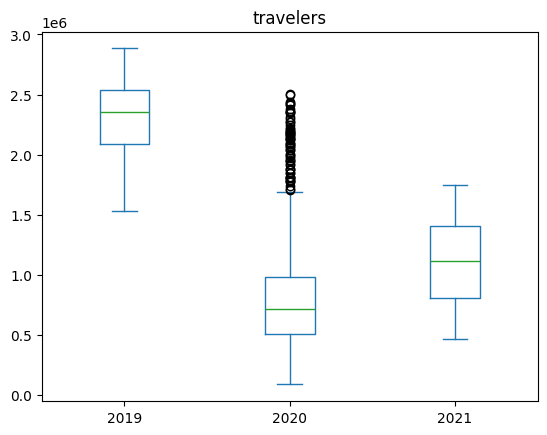

In [148]:
df_t.plot(kind="box", by='year')

<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

In [152]:
# Your code here
import seaborn as sns
import matplotlib.pyplot as plt
df_t['date'] = pd.to_datetime(df_t['date'])

In [161]:
df_2019 = df_t[df_t['year'] == 2019].copy()
df_2019["day of week"] = df_2019['date'].dt.day_name()
df_2019["month"] = df_2019['date'].dt.month_name()
df_2019

,date,year,travelers,holiday,day of week,month
0,2019-01-01,2019,2126398.0,New Year's Day,Tuesday,January
1,2019-01-02,2019,2345103.0,New Year's Day,Wednesday,January
2,2019-01-03,2019,2202111.0,NaN,Thursday,January
3,2019-01-04,2019,2150571.0,NaN,Friday,January
4,2019-01-05,2019,1975947.0,NaN,Saturday,January
...,...,...,...,...,...,...
360,2019-12-27,2019,2575985.0,NaN,Friday,December
361,2019-12-28,2019,2500396.0,NaN,Saturday,December
362,2019-12-29,2019,2009880.0,New Year's Eve,Sunday,December
363,2019-12-30,2019,2133253.0,New Year's Eve,Monday,December


In [164]:
pivot = df_2019.pivot_table(
    index='day of week',
    columns='month',
    values='travelers',
    aggfunc='median'

)

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

pivot = pivot.reindex(index=dow_order)
pivot = pivot.reindex(columns=month_order)

pivot

month,January,February,March,April,May,June,July,August,September,October,November,December
day of week,,,,,,,,,,,,
Monday,1965342.5,2108074.5,2495543.0,2499461.0,2513732.5,2530726.5,2542365.0,2349372.0,2082179.0,2230216.0,2110044.5,2054380.0
Tuesday,1733739.0,1758577.0,2551498.0,2521897.0,2633590.0,2693454.0,2705399.0,2581777.5,2452356.0,2541581.0,2396507.5,2392331.0
Wednesday,1763884.0,1982732.0,2200050.5,2001089.5,2570613.0,2729187.5,2730936.0,2643061.0,2515818.0,2594337.0,2490780.5,2485304.5
Thursday,1991328.0,2267561.5,2526468.5,2454865.0,2124825.0,2343896.0,2355385.5,2171962.0,1909112.0,1931971.0,2051548.0,2182328.5
Friday,2101692.5,2106456.5,2378673.0,2448675.0,2512315.0,2655971.5,2714039.0,2584444.0,2468865.0,2548725.5,2396681.0,2409823.5
Saturday,1602780.0,1897686.5,2122898.0,2155378.0,2351812.0,2644981.0,2625213.5,2567986.0,2387325.0,2457413.0,2403304.0,2370444.5
Sunday,1990412.0,2151817.0,2187298.0,2255325.5,2328201.0,2433189.0,2473318.5,2277137.5,2013050.0,2081132.5,2077552.0,2009112.0


<Axes: xlabel='month', ylabel='day of week'>

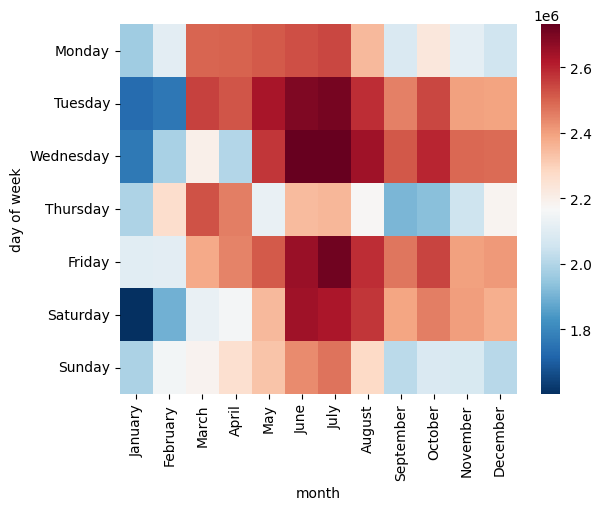

In [175]:
sns.heatmap(pivot, cmap="RdBu_r")